# Skyrmion in a disk

In this example, we stabilize a single Skyrmion in a circular shaped thin film.

## Simulation

### Import libraries

In [1]:
from pathlib import Path
import sys

import pyvista as pv
from scipy import constants

import neuralmag as nm

repo_root = Path.cwd().resolve()
if not (repo_root / "demos").exists():
    for parent in repo_root.parents:
        if (parent / "demos").exists():
            repo_root = parent
            break
sys.path.insert(0, str(repo_root / "demos"))

from _static_method_compare import SOLVER_LABELS, compare_static_methods, print_static_method_summary

pv.set_jupyter_backend("static")

METHODS = ("llg", "bb")

2026-04-22 13:15:52 NeuralMag:INFO [NeuralMag] Version 0.9.4


### Create mesh and state
We create a 2D nodal mesh (mesh with just 1 layer of nodes in the z-direction) with $50 \times 50$ cells with cell size $2 \times 2 \times 0.6\,\text{nm}^3$.

In [2]:
mesh = nm.Mesh((50, 50), (2e-9, 2e-9, 0.6e-9), (-50e-9, -50e-9, 0))
state = nm.State(mesh)

2026-04-22 13:15:53 NeuralMag:INFO [Mesh] 2D, 50 x 50 (size = 2e-09 x 2e-09 x 6e-10)
2026-04-22 13:15:53 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2026-04-22 13:15:53 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-22 13:15:53 NeuralMag:INFO [NeuralMag] Set default dtype to 'float32'.
E0422 13:15:59.078537  875902 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 106.88GiB (114756157440 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0422 13:16:04.178898  875902 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 96.19GiB (103280541696 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0422 13:16:09.332131  875902 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 86.57GiB (92952485888 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0422 13:16:14.474804  875902 cuda_executor.cc

### Set material parameters

In [3]:
state.material.Ms = 1.0 / constants.mu_0
state.material.A = 1.6e-11
state.material.Di = 4e-3
state.material.Di_axis = [0, 0, 1]
state.material.Ku = 510e3
state.material.Ku_axis = [0, 0, 1]
state.material.alpha = 0.1

### Define circular geometry
Initialize geometry by defining a circular domain with ID 1.

In [4]:
x, y = state.coordinates()
state.add_domain(1, x**2.0 + y**2.0 < 50e-9**2.0)

### Set initial magnetization

In [5]:
state.m = nm.VectorFunction(state).fill((0, 0, 1))

### Register effective field
The effective field comprises exchange, demag, interface DMI and uniaxial anisotropy contributions

In [6]:
nm.ExchangeField().register(state, "exchange")
nm.DemagField().register(state, "demag")
nm.InterfaceDMIField().register(state, "dmi")
nm.UniaxialAnisotropyField().register(state, "aniso")
nm.TotalField("exchange", "demag", "dmi", "aniso").register(state)

2026-04-22 13:16:53 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-22 13:16:53 NeuralMag:INFO [DemagField] Generate jax core methods
Generating...: 100%|██████████| 4/4 [00:00<00:00, 247.89it/s]
2026-04-22 13:16:55 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-22 13:16:55 NeuralMag:INFO [VectorCellFunction] Generate jax core methods
Generating...: 100%|██████████| 1/1 [00:00<00:00, 590.50it/s]
2026-04-22 13:16:55 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-22 13:16:59 NeuralMag:INFO [InterfaceDMIField] Generate jax core methods
Generating...: 100%|██████████| 4/4 [00:00<00:00, 246.65it/s]
2026-04-22 13:17:06 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_dmi', energy: 'E_dmi', energy density: 'e_dmi')
2026-04-22 13:17:06 NeuralMag:INFO [UniaxialAnisotropyField] Generate jax core methods


### Relax to the skyrmion configuration and compare minimizers
We compare the damped-LLG relaxer and the BB steepest-descent minimizer by rebuilding the same disk problem for each method, then writing both equilibria to disk for side-by-side visualization.

In [ ]:
def build_state():
    mesh = nm.Mesh((50, 50), (2e-9, 2e-9, 0.6e-9), (-50e-9, -50e-9, 0))
    state = nm.State(mesh)

    state.material.Ms = 1.0 / constants.mu_0
    state.material.A = 1.6e-11
    state.material.Di = 4e-3
    state.material.Di_axis = [0, 0, 1]
    state.material.Ku = 510e3
    state.material.Ku_axis = [0, 0, 1]
    state.material.alpha = 0.1

    x, y = state.coordinates()
    state.add_domain(1, x**2.0 + y**2.0 < 50e-9**2.0)

    state.m = nm.VectorFunction(state).fill((0, 0, 1))

    nm.ExchangeField().register(state, "exchange")
    nm.DemagField().register(state, "demag")
    nm.InterfaceDMIField().register(state, "dmi")
    nm.UniaxialAnisotropyField().register(state, "aniso")
    nm.TotalField("exchange", "demag", "dmi", "aniso").register(state)
    return state

comparison = compare_static_methods(
    build_state,
    methods=METHODS,
    llg_builder=lambda state: nm.LLGSolver(state, scale_t=1e-12),
    llg_runner=lambda solver: solver.relax(1e9),
)
print_static_method_summary("Skyrmion disk", comparison)

for method, values in comparison.items():
    values["state"].write_vti(["m", "rho", "e"], f"skyrmion-disk/m-{method}.vti")

2026-04-22 13:17:09 NeuralMag:INFO [Mesh] 2D, 50 x 50 (size = 2e-09 x 2e-09 x 6e-10)
2026-04-22 13:17:09 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-22 13:17:09 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-22 13:17:09 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-22 13:17:09 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-22 13:17:09 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-22 13:17:11 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_dmi', energy: 'E_dmi', energy density: 'e_dmi')
2026-04-22 13:17:11 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso', energy density: 'e_aniso')
2026-04-22 13:17:11 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E'

JaxRuntimeError: INTERNAL: RET_CHECK failure (external/xla/xla/backends/gpu/runtime/fft_thunk.cc:199) fft_plan != nullptr Failed to create cuFFT batched plan with scratch allocator

: 

## Visualization
We use pyvista to visualize the resulting skyrmion for both minimizers side by side, using a threshold filter on `state.rho` so that only the magnetic region is shown.

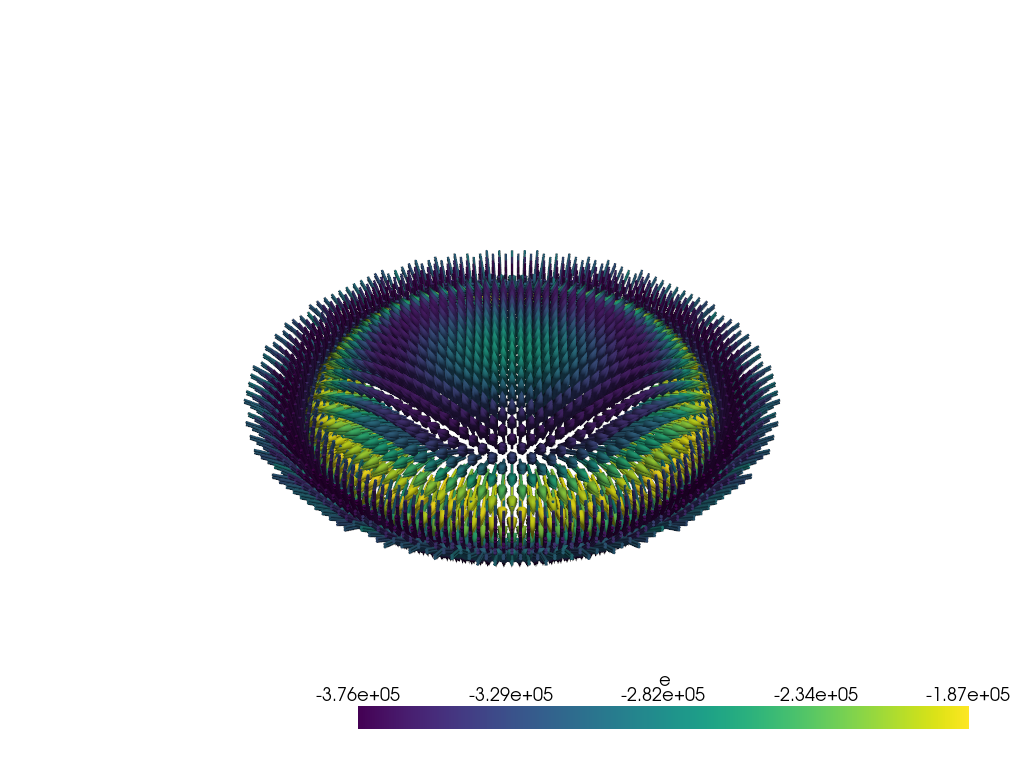

In [ ]:
plotter = pv.Plotter(shape=(1, len(METHODS)))
for column, method in enumerate(METHODS):
    grid = pv.read(f"skyrmion-disk/m-{method}.vti")
    thresholded = grid.threshold(value=0.5, scalars="rho", preference="cell")
    glyphs = thresholded.glyph(orient="m", scale="m", factor=1e-8)

    plotter.subplot(0, column)
    plotter.add_text(SOLVER_LABELS[method], font_size=12)
    plotter.add_mesh(glyphs, scalars="e", lighting=True, smooth_shading=True)

plotter.link_views()
plotter.show()